In [2]:
import sys
sys.path.append('..')
import phd_ms
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

In [3]:

#Change this line to the directory where inputs are stored

INPUT_FILE= '/home/pbeamer/Documents/h5ad/graphst/visium_hne_graphst.h5ad'

#Set fields of anndata where ground truth and embedding for clustering are stored
EMBEDDING = 'X_gst'

#Set the scale parameters we want to use, and keys to save
RESOLUTIONS = np.linspace(start=0.15,stop=.95,num=8)
RES_KEYS = [f'leiden_{r:.3f}' for r in RESOLUTIONS]

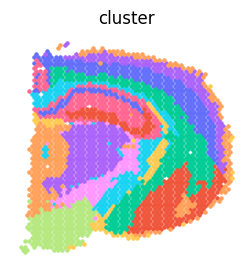

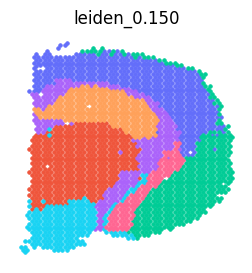

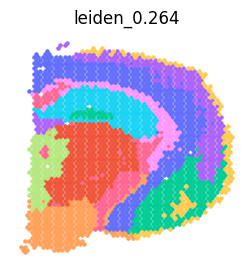

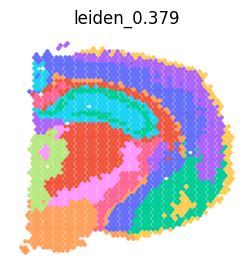

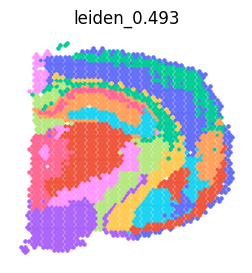

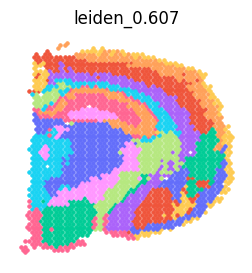

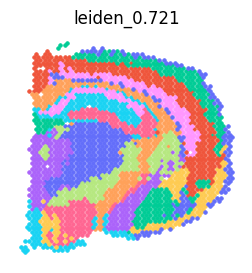

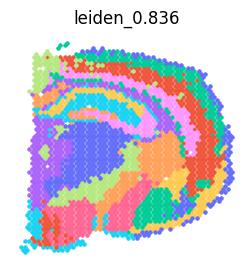

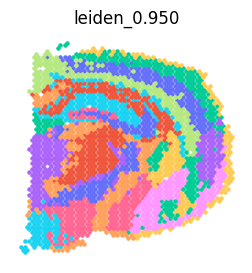

In [4]:

#Preprocess clusterings for each resolution
adata = phd_ms.tl.preprocess_leiden(INPUT_FILE,output_file=INPUT_FILE, reflect=['y'], plots=True,
                            emb=EMBEDDING,resolution=RESOLUTIONS,res_keys=RES_KEYS,neighbors=5)

Constructing filtration...


100%|██████████| 7/7 [00:14<00:00,  2.13s/it]


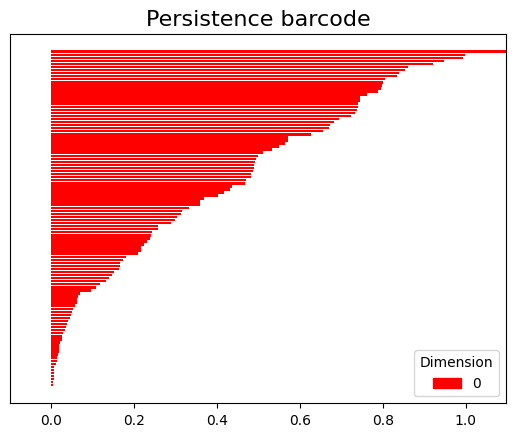

In [9]:
#Build cluster filtration
cluster_complex,clusterings= phd_ms.tl.cluster_filtration(adata,res_keys=RES_KEYS,index='jaccard')
#Plot persistence diagram
from gudhi import plot_persistence_barcode
from gudhi import SimplexTree
plot_persistence_barcode(cluster_complex.persistence(),colormap=((1,0,0),),alpha=1);
plt.savefig('/home/pbeamer/Documents/mouse_brainpersistence_barcode.png',dpi=300)

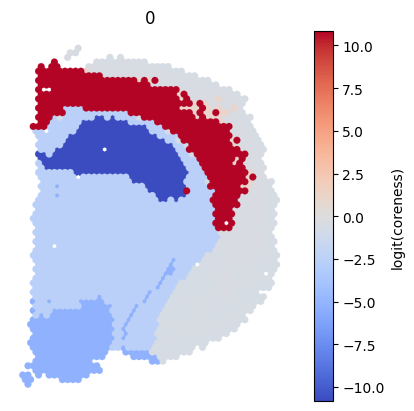

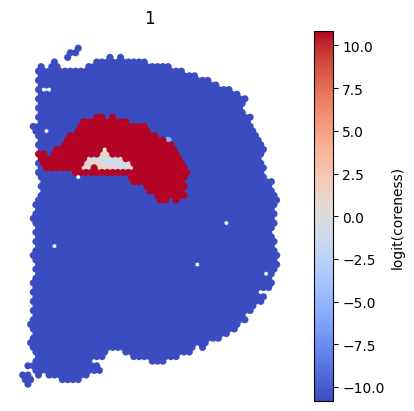

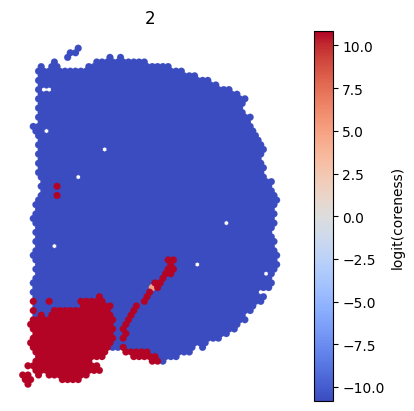

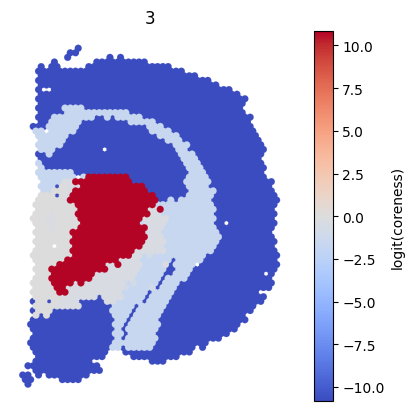

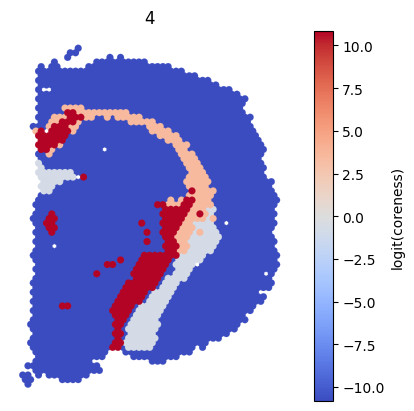

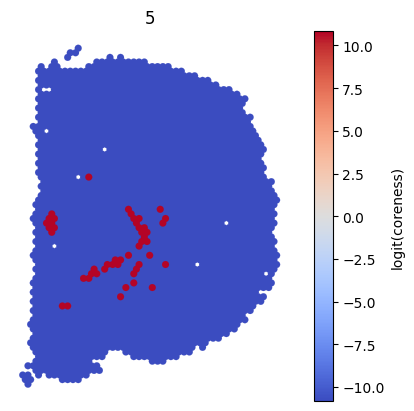

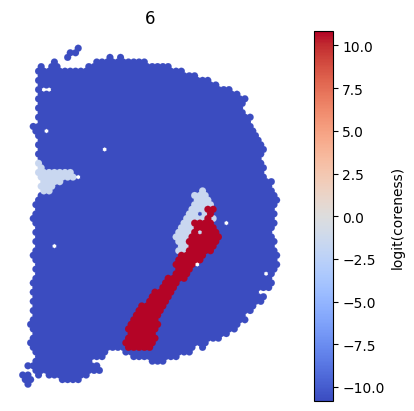

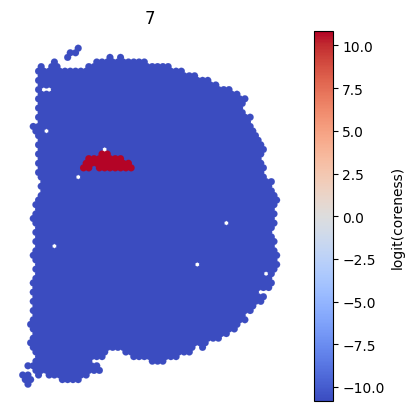

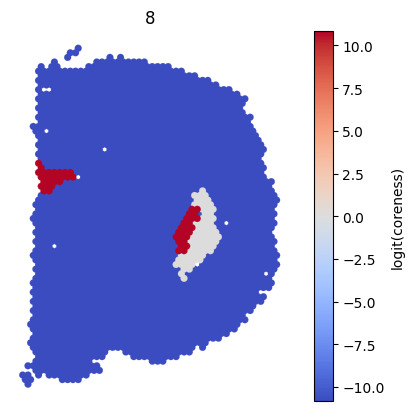

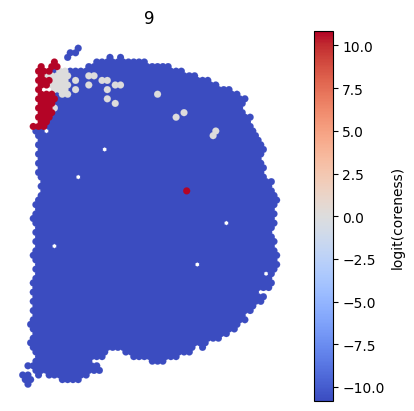

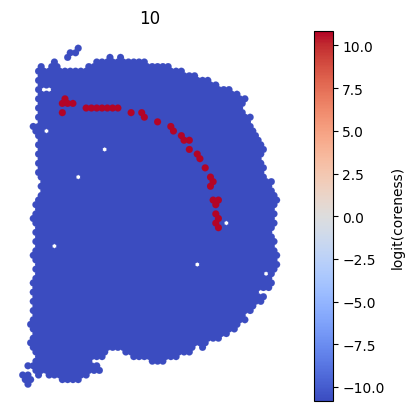

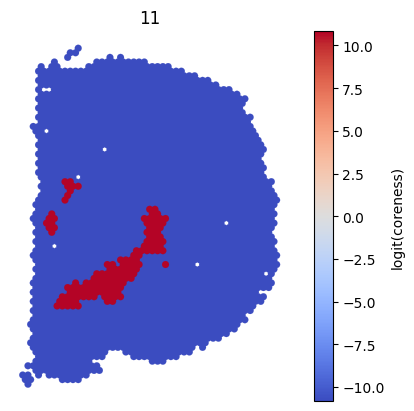

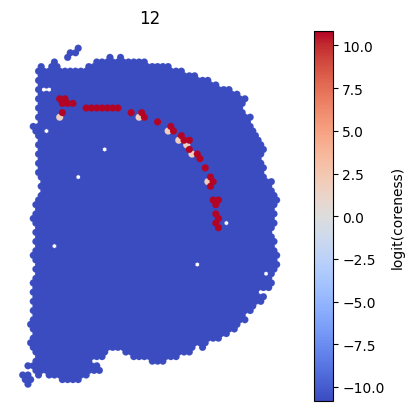

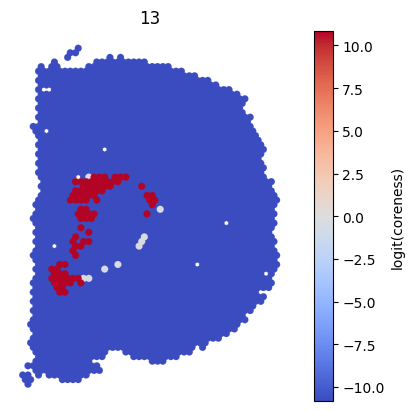

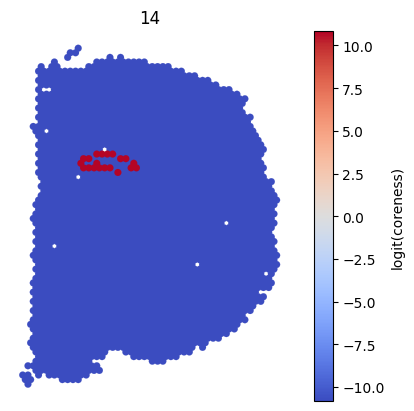

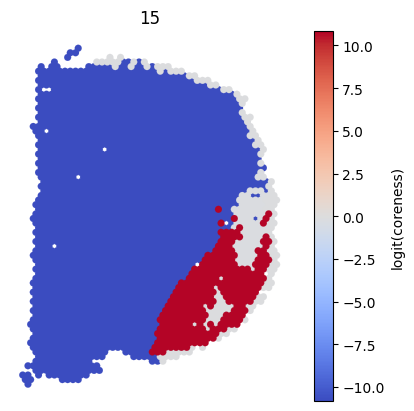

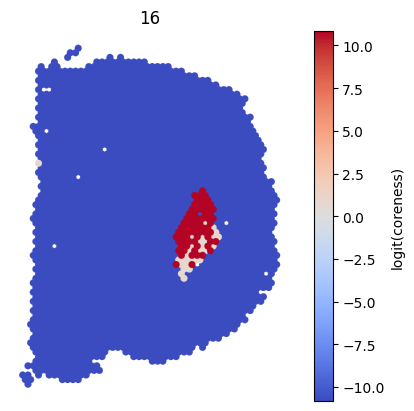

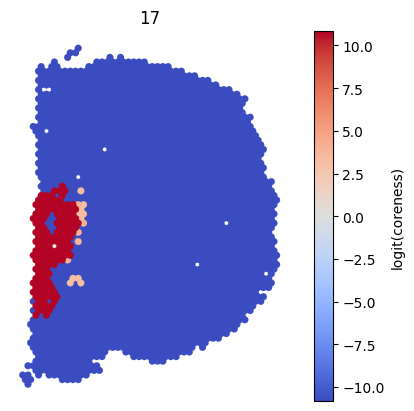

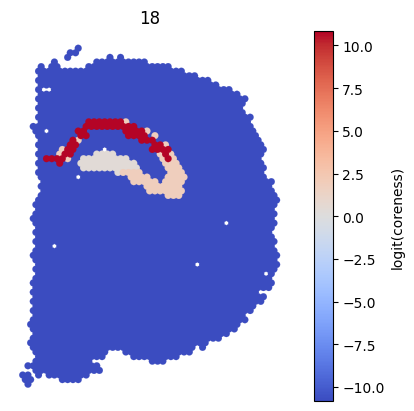

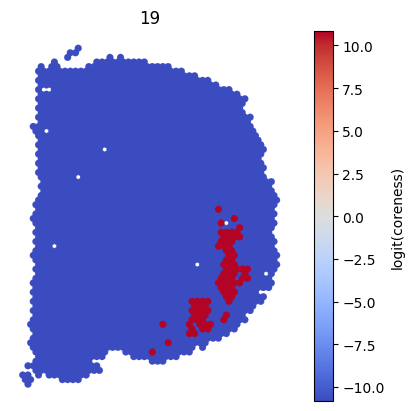

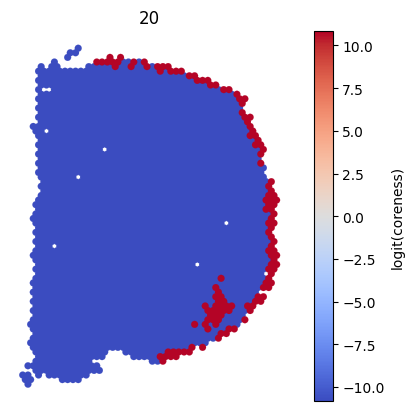

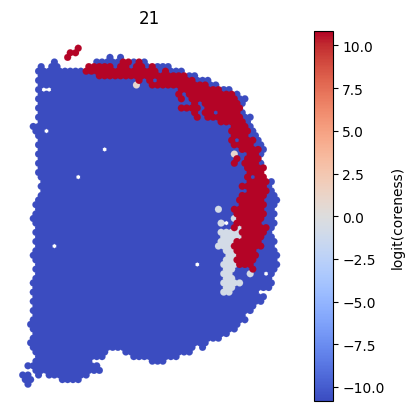

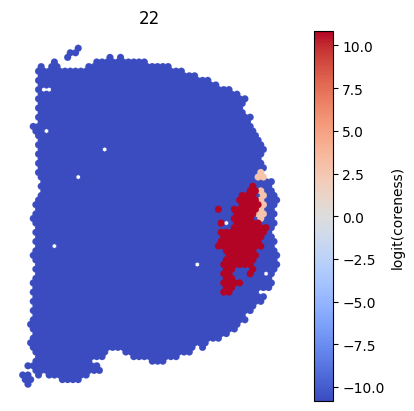

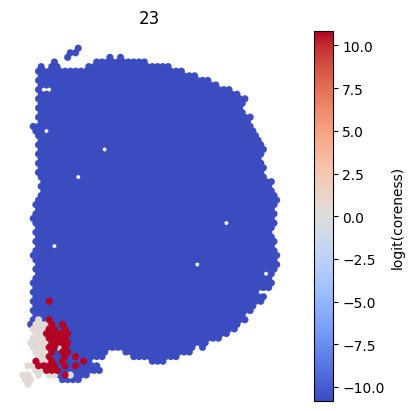

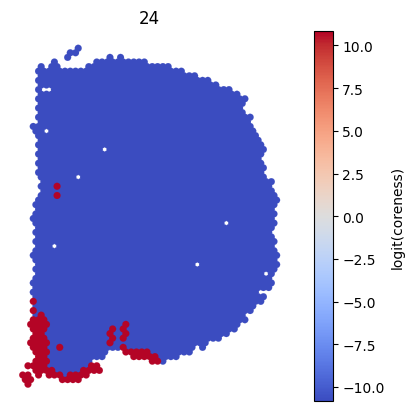

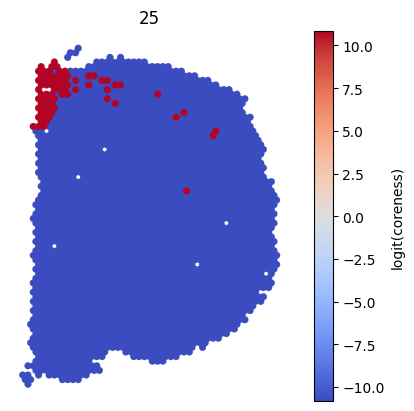

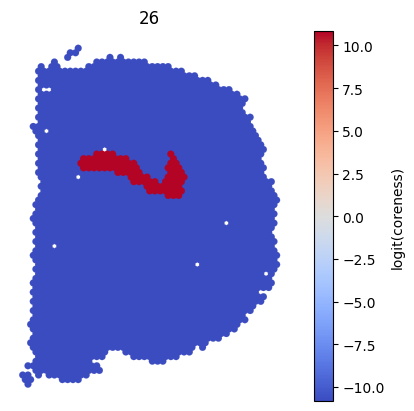

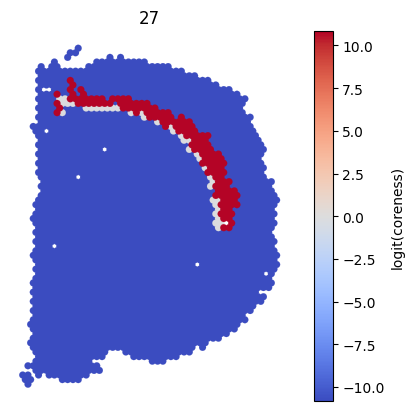

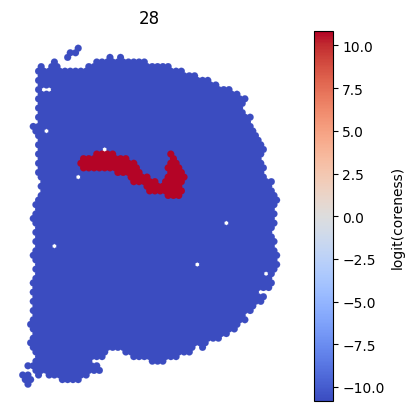

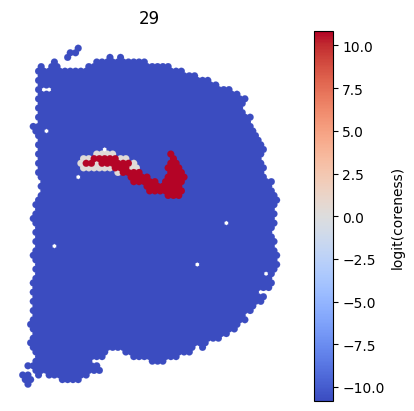

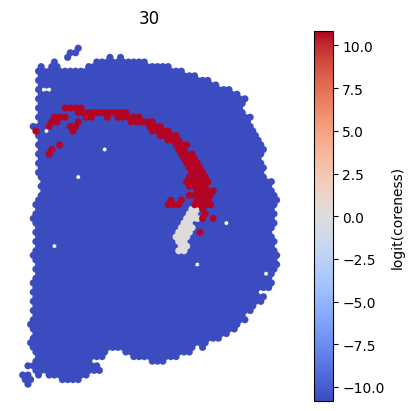

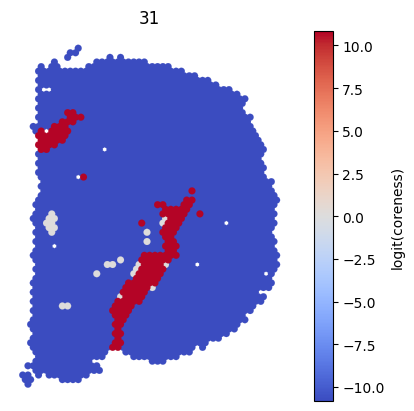

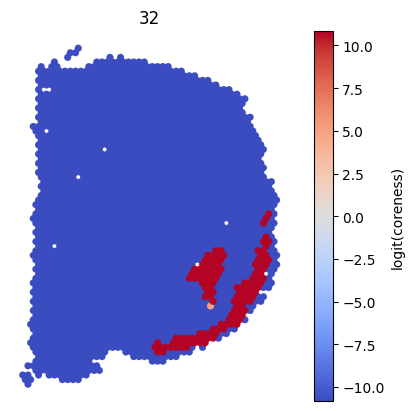

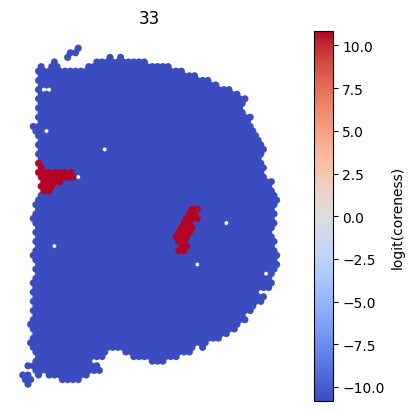

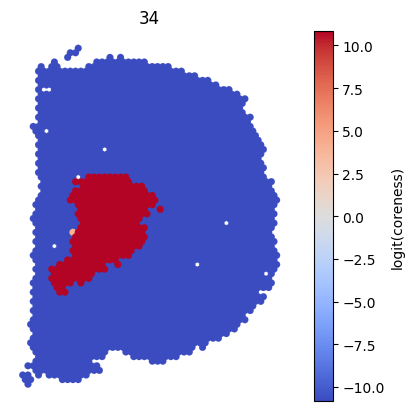

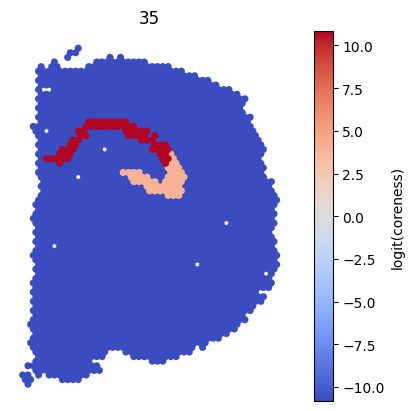

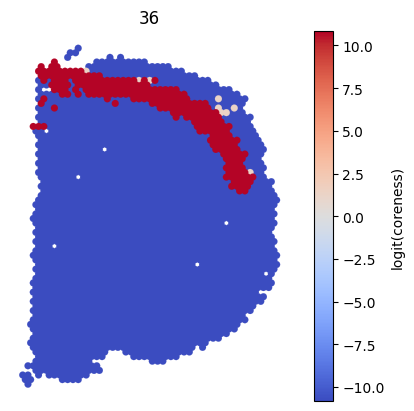

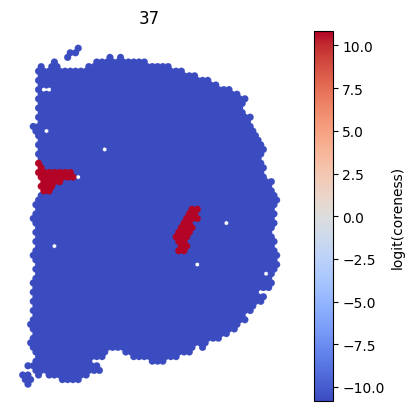

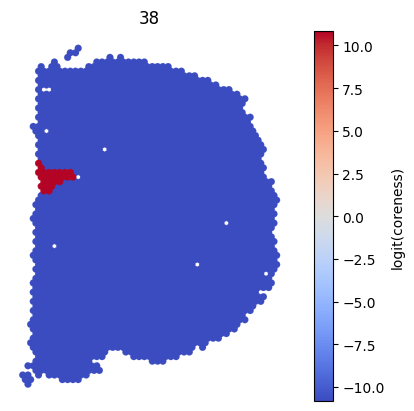

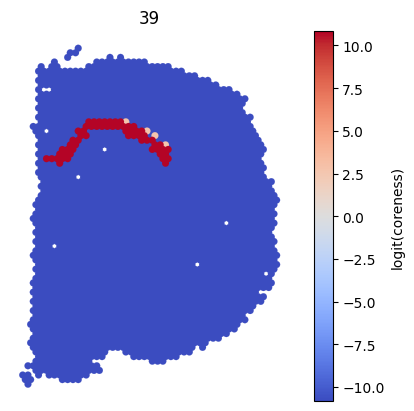

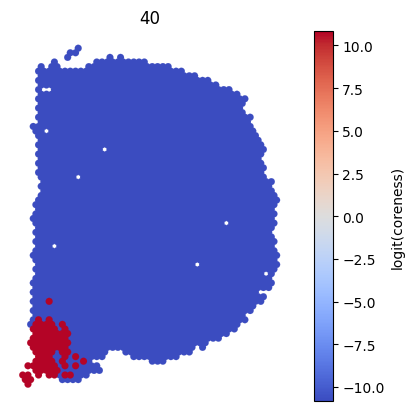

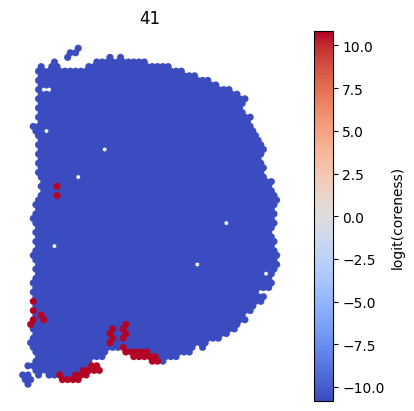

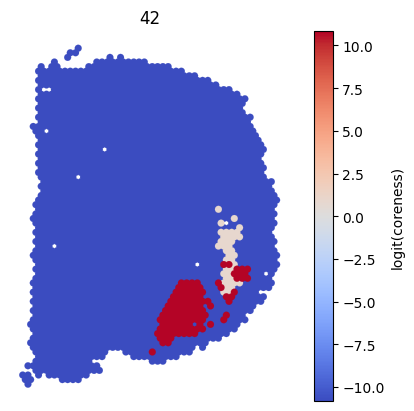

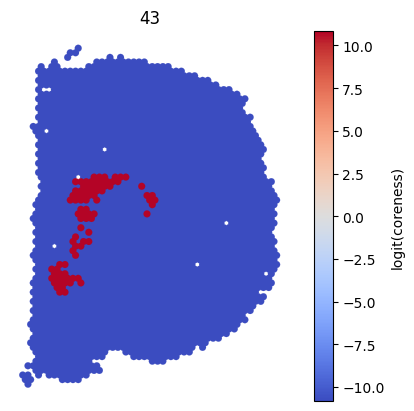

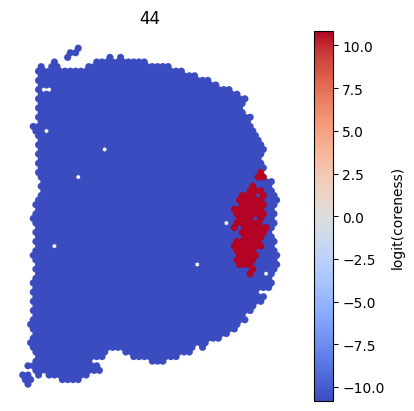

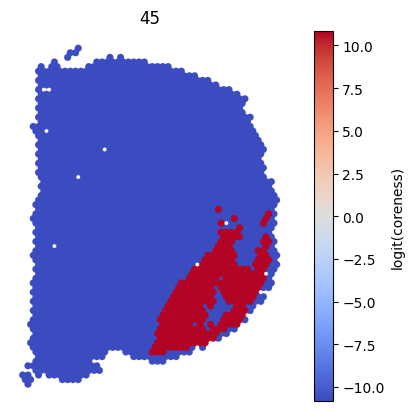

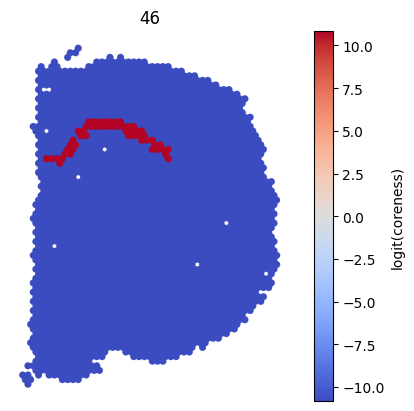

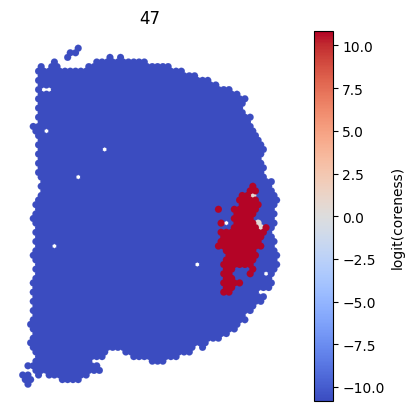

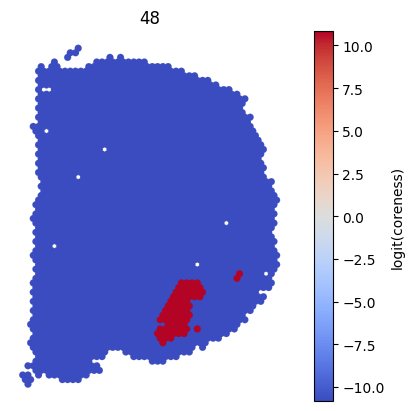

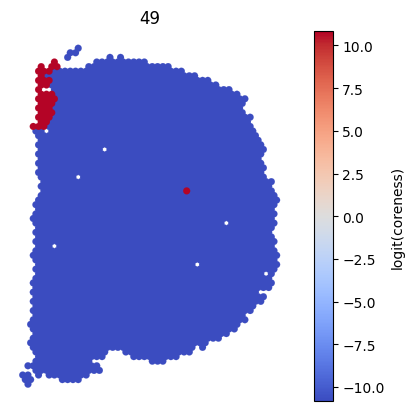

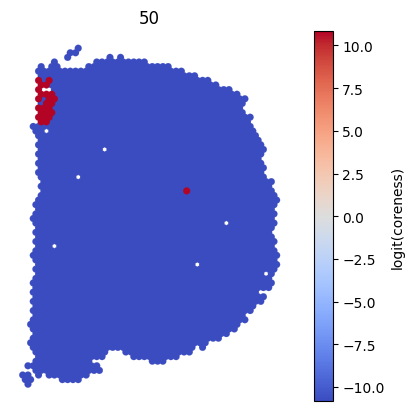

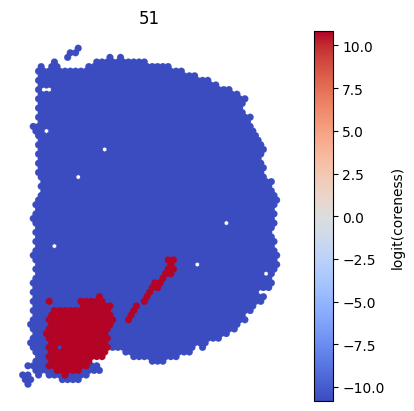

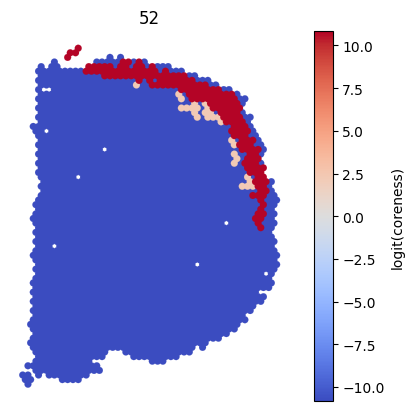

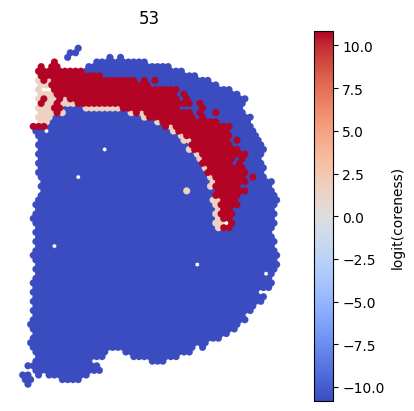

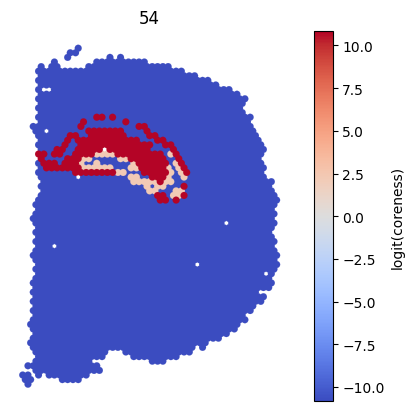

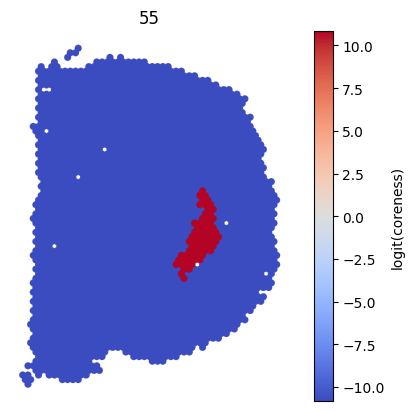

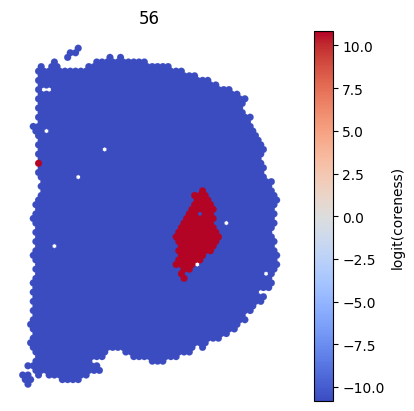

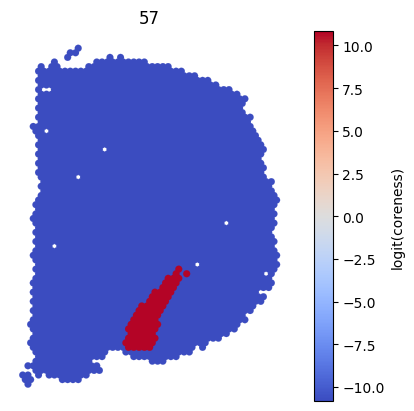

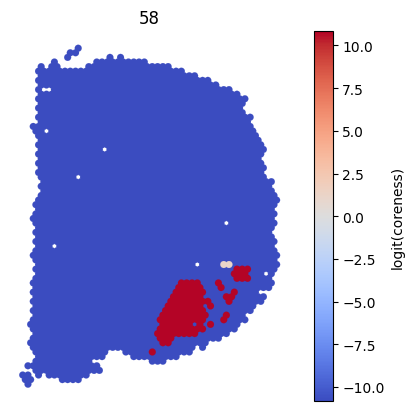

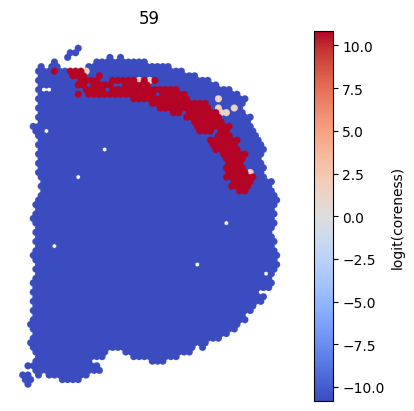

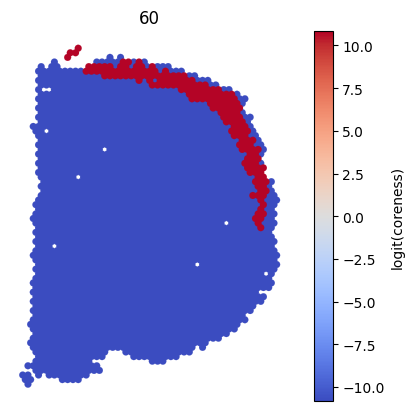

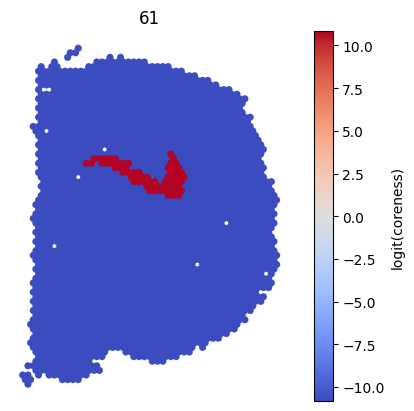

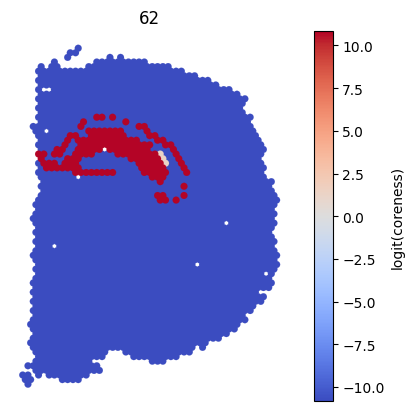

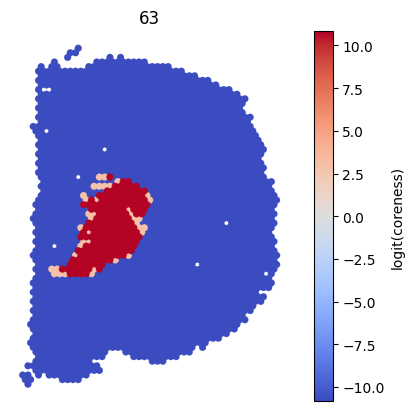

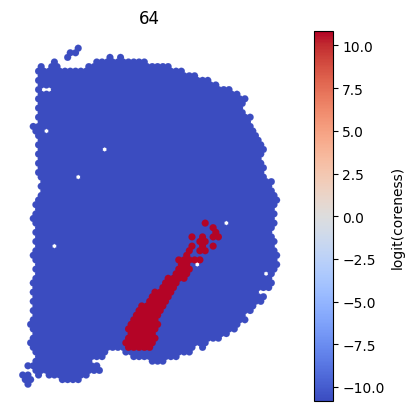

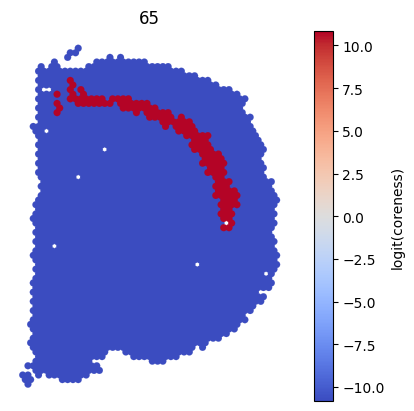

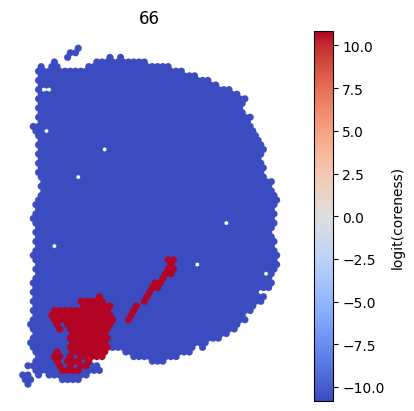

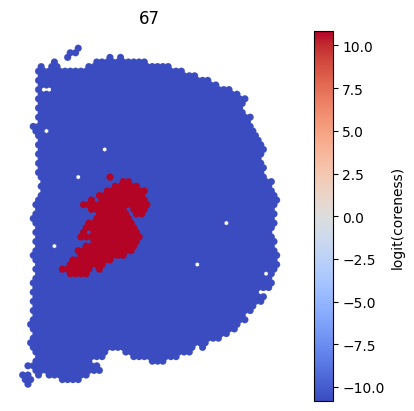

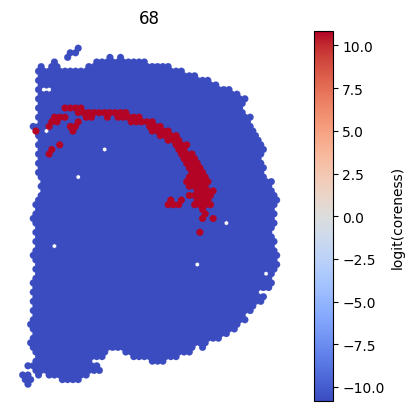

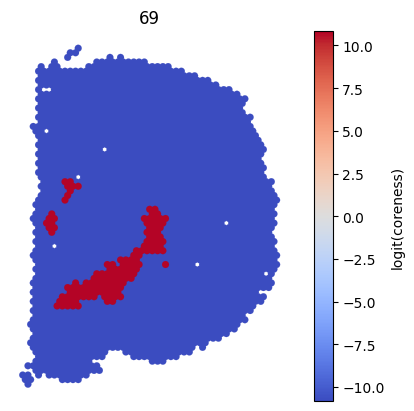

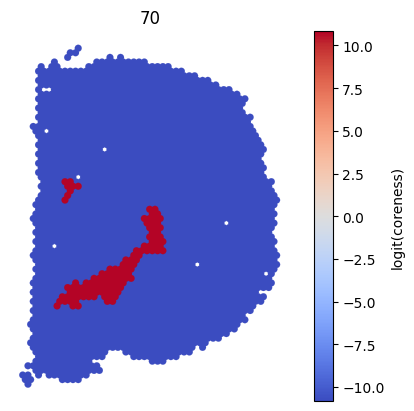

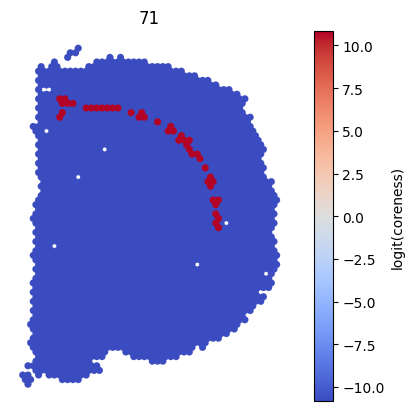

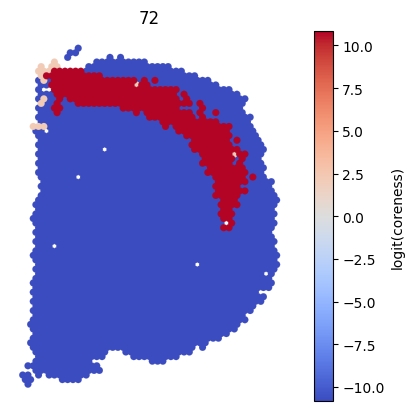

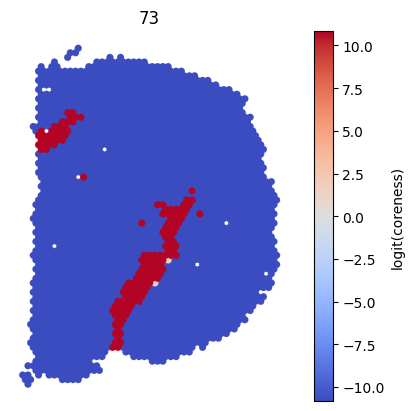

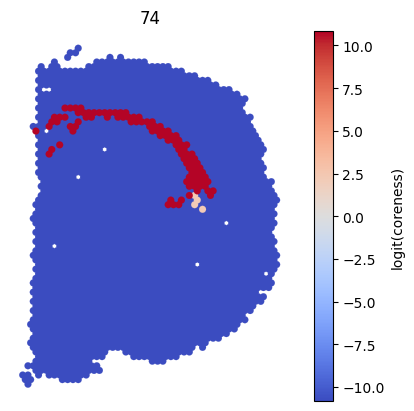

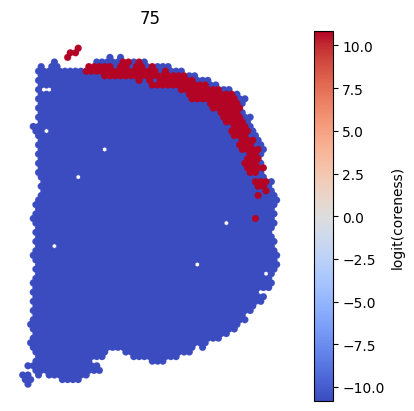

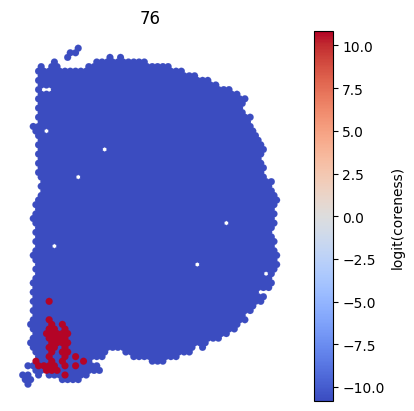

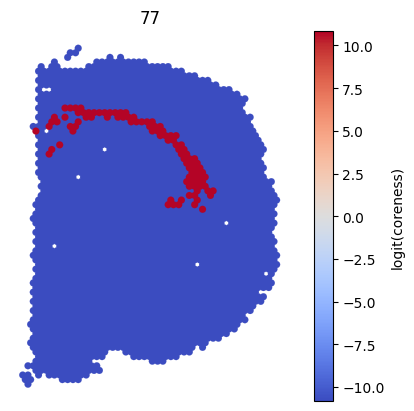

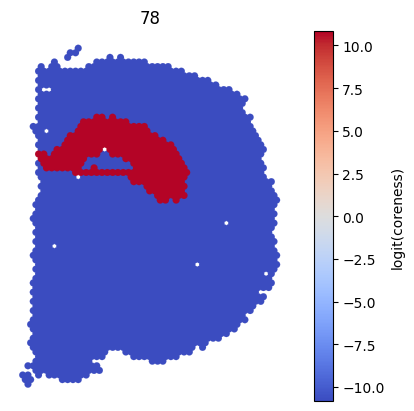

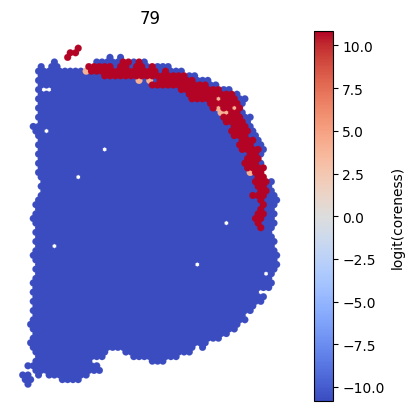

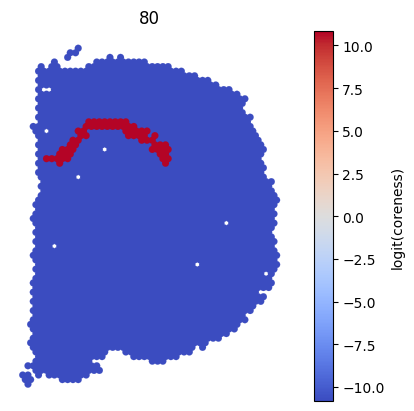

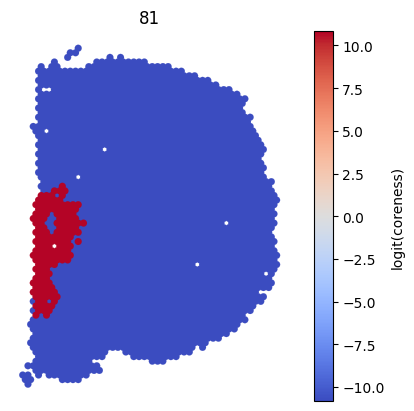

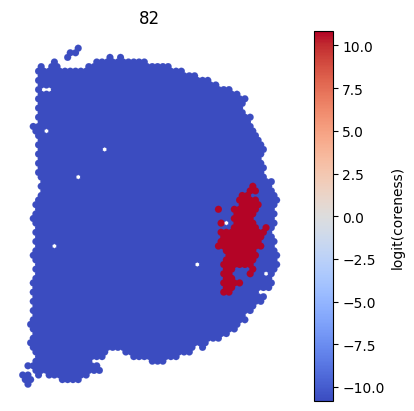

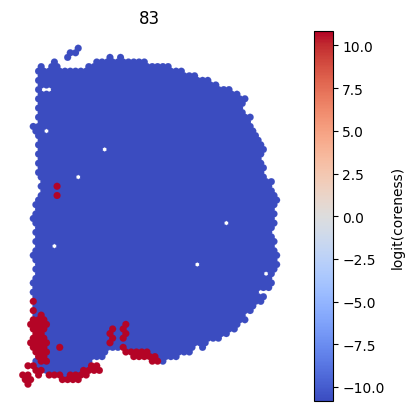

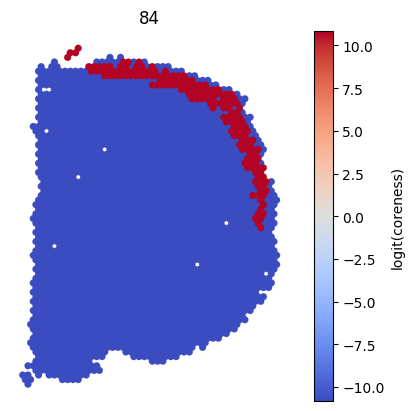

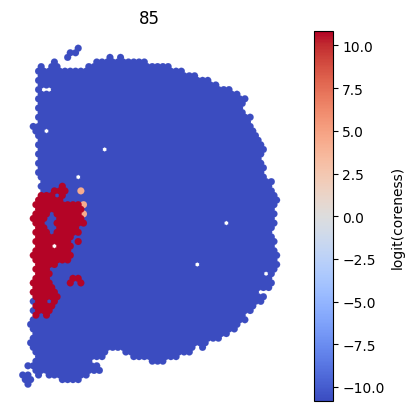

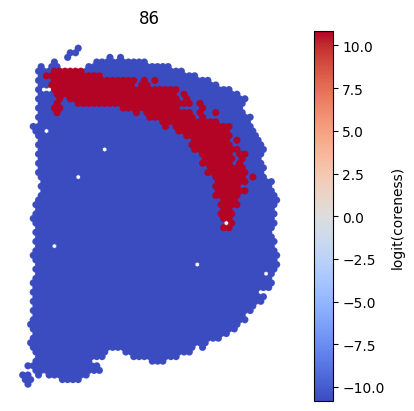

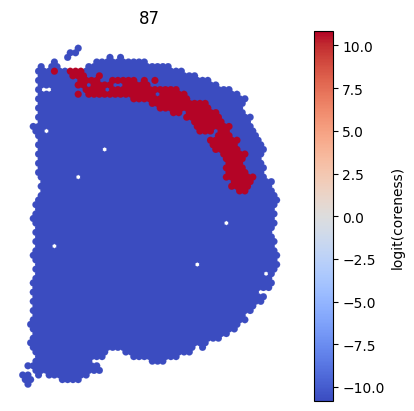

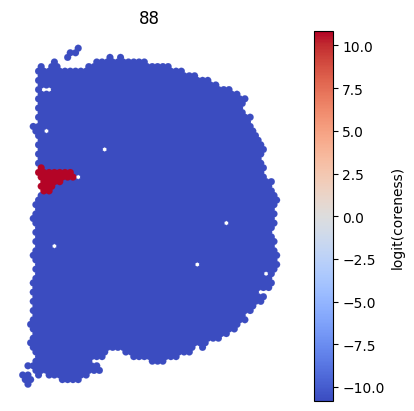

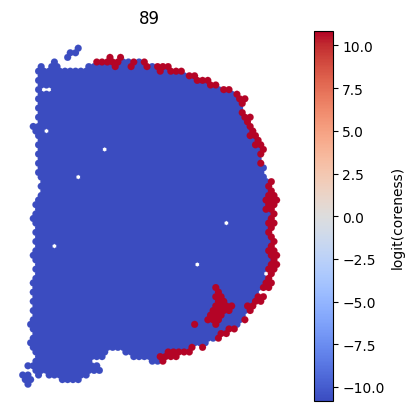

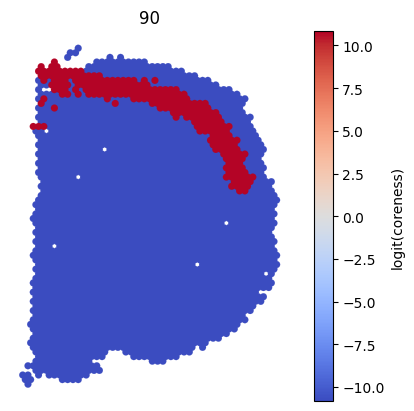

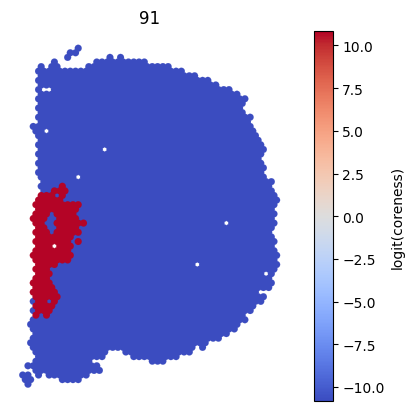

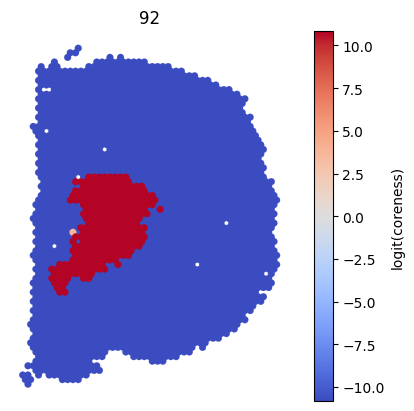

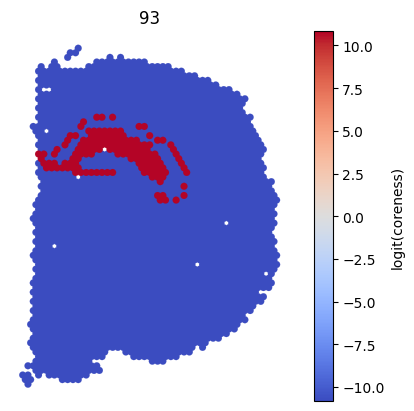

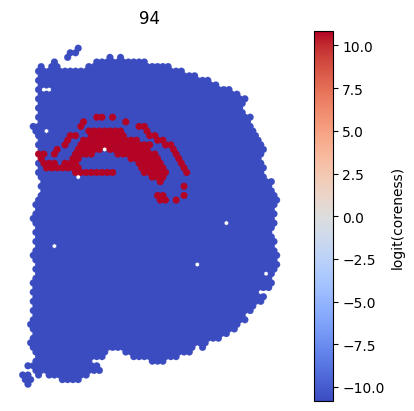

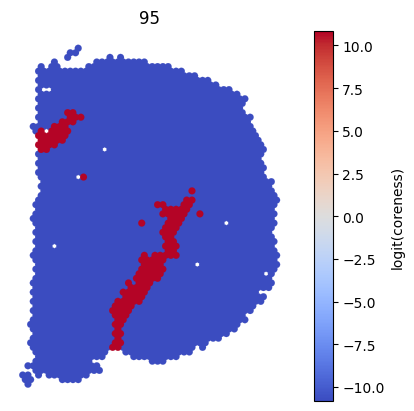

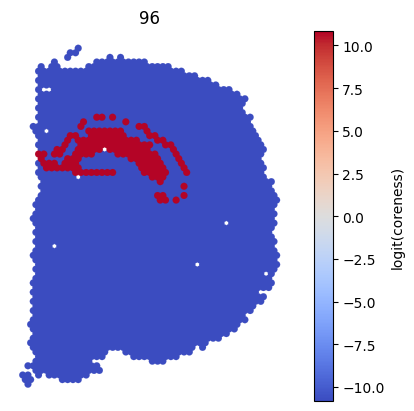

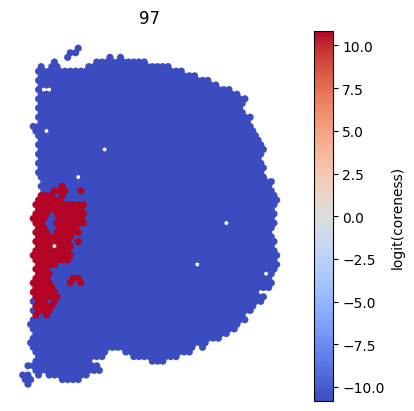

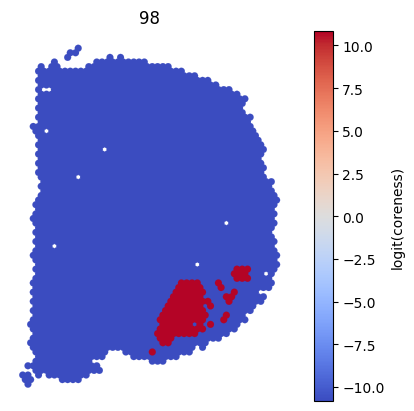

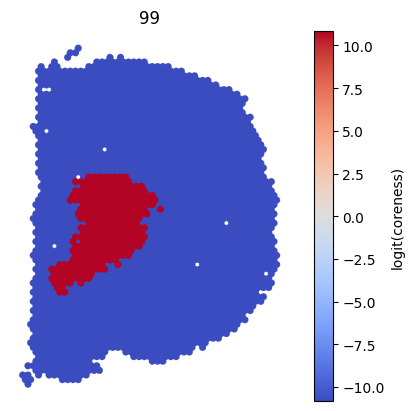

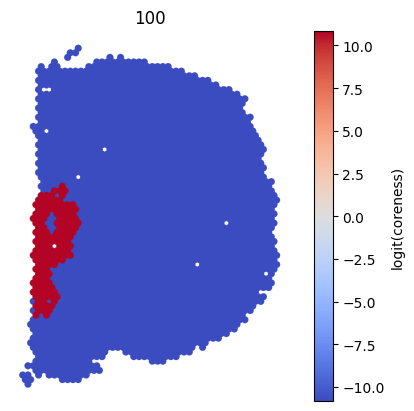

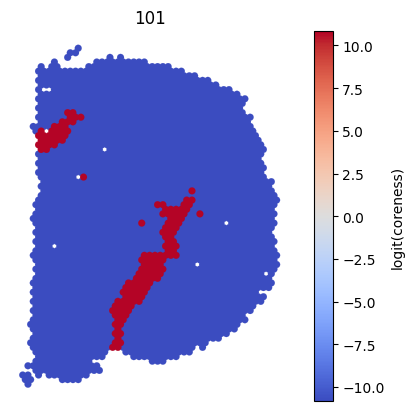

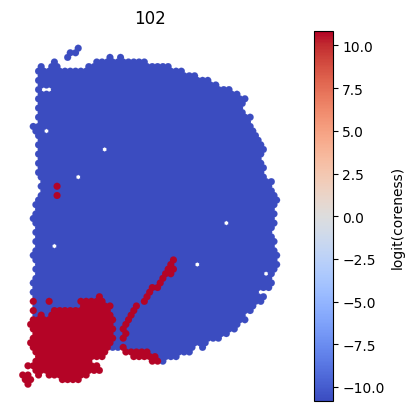

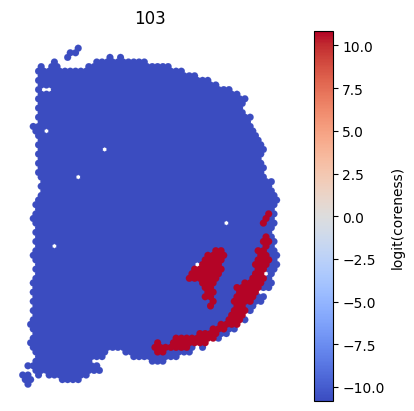

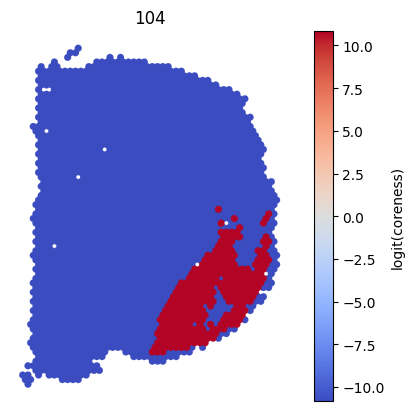

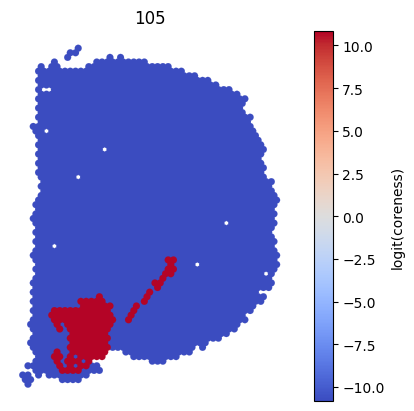

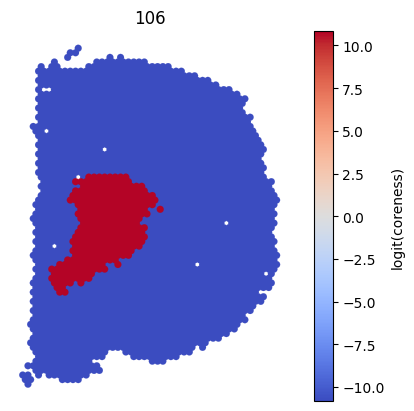

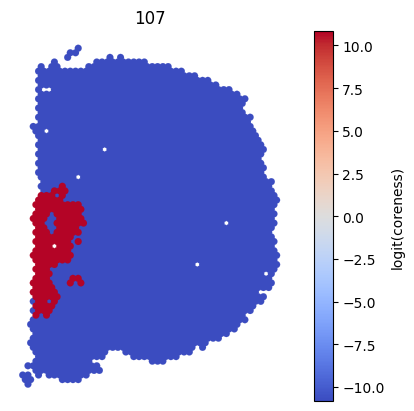

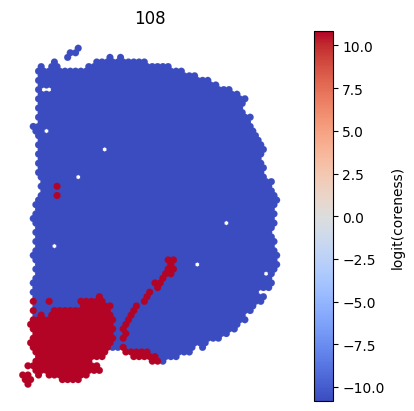

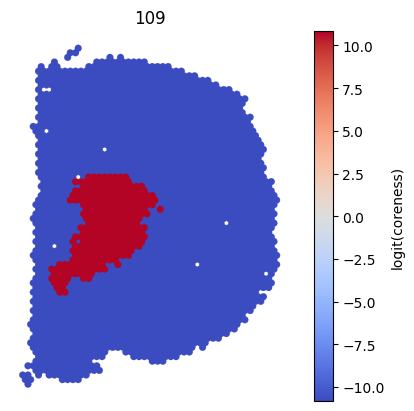

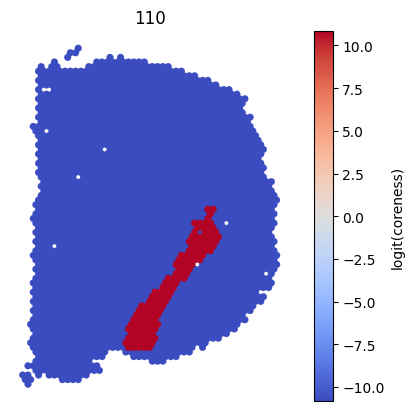

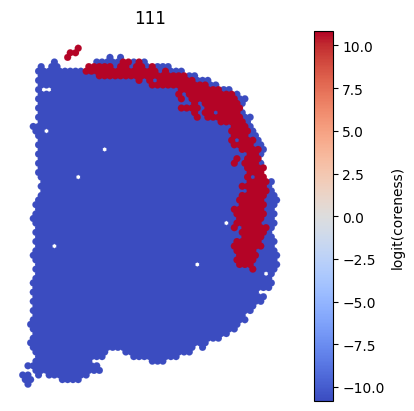

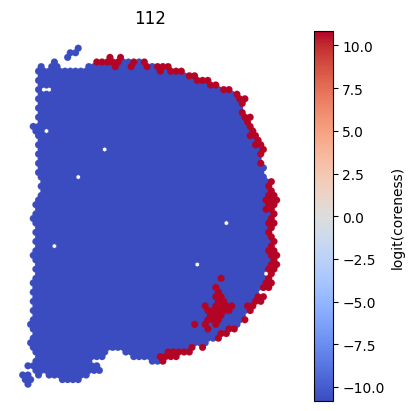

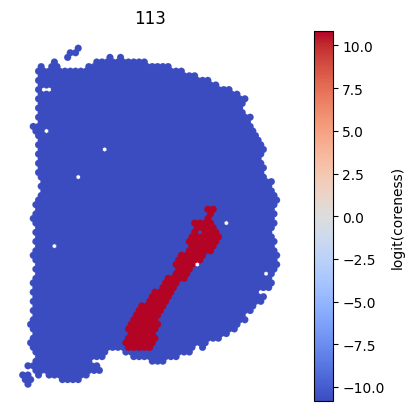

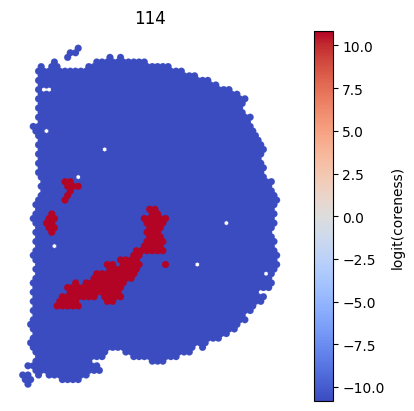

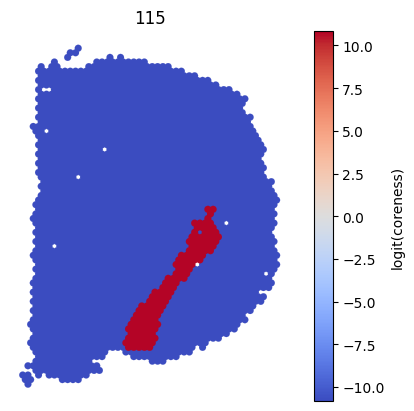

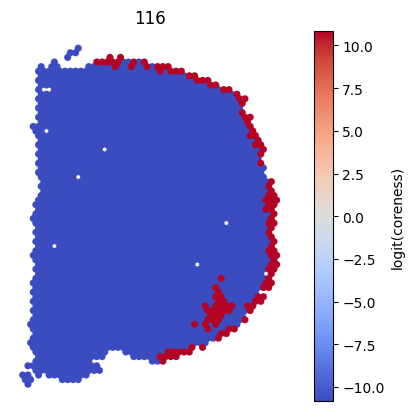

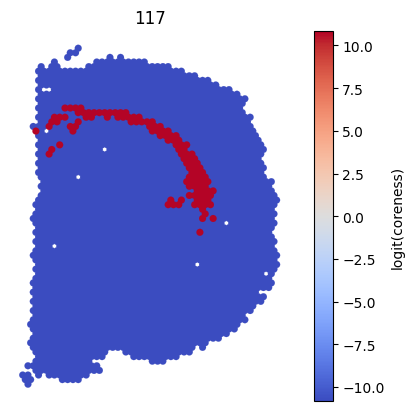

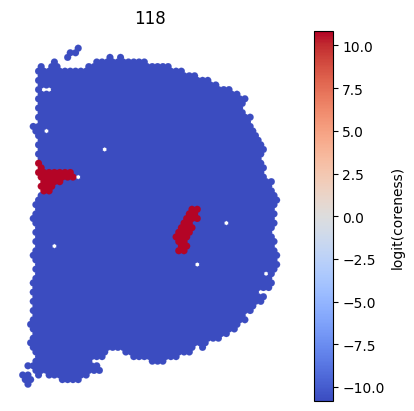

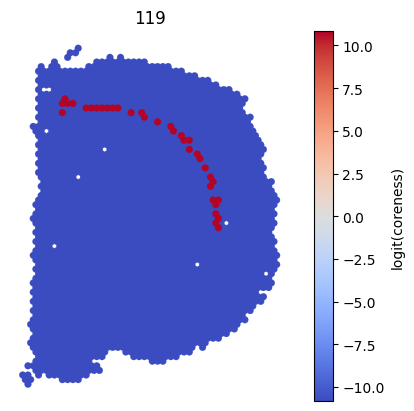

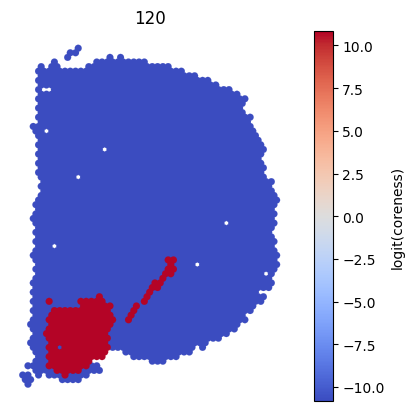

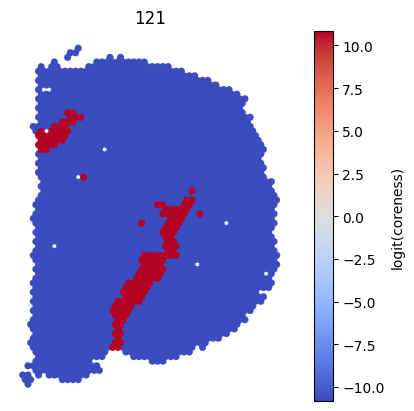

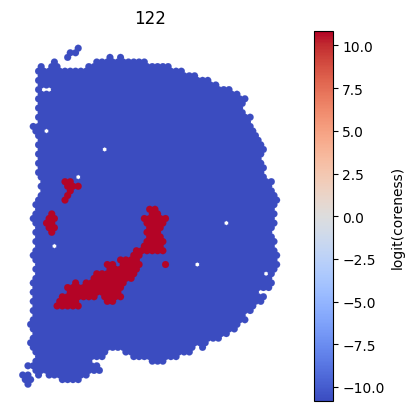

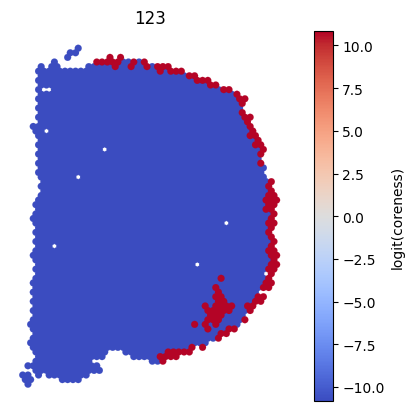

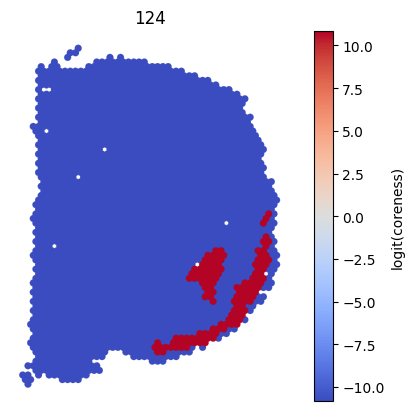

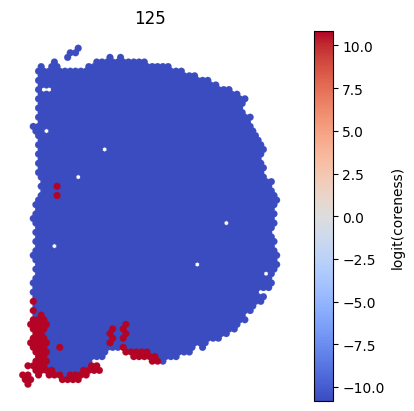

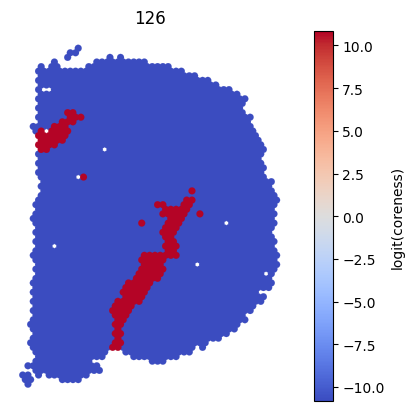

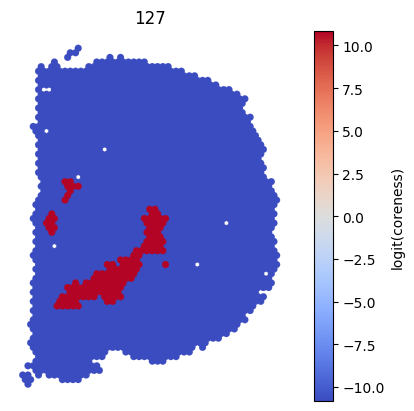

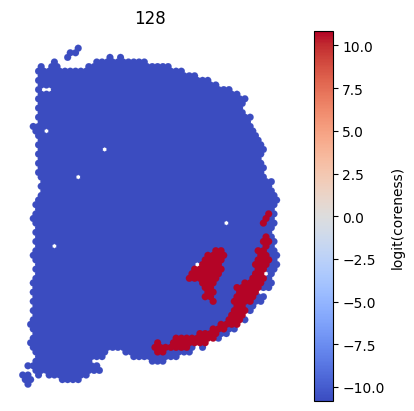

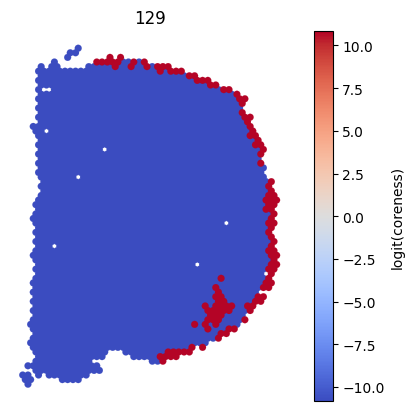

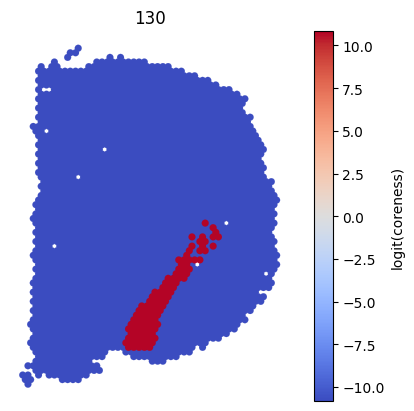

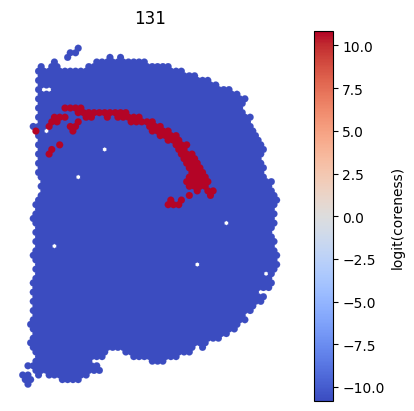

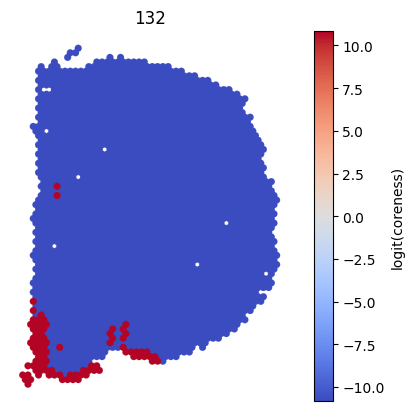

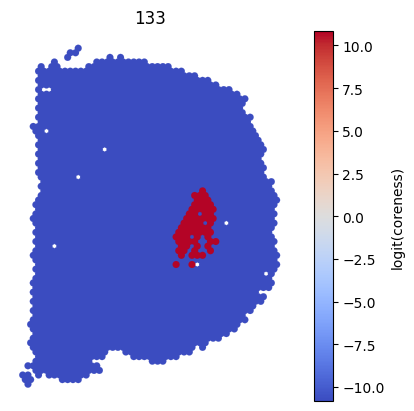

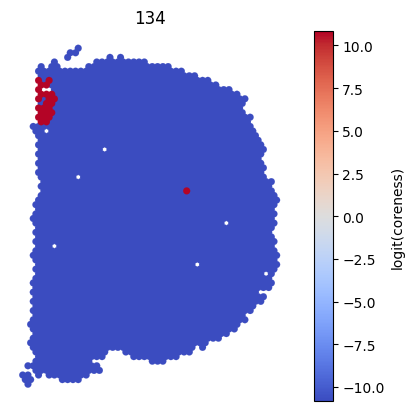

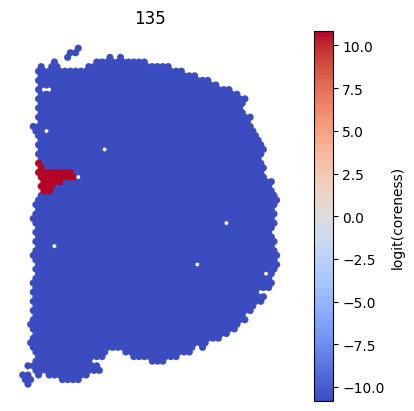

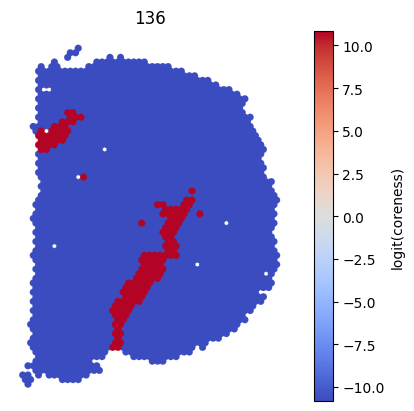

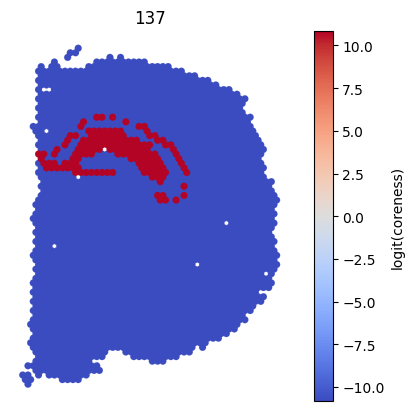

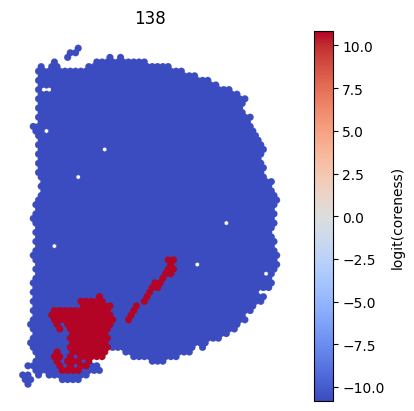

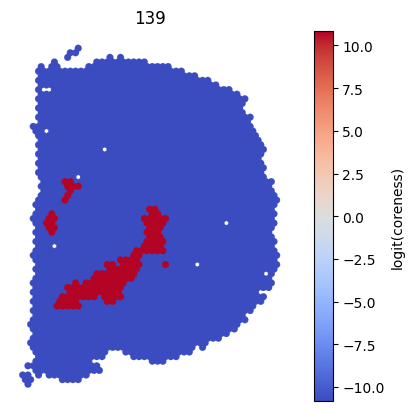

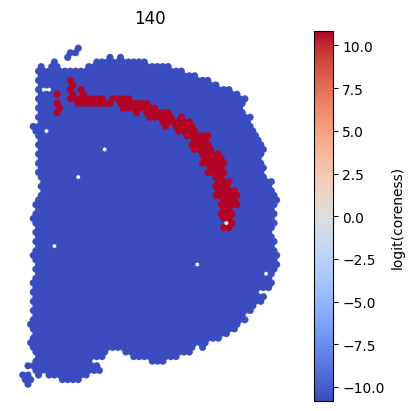

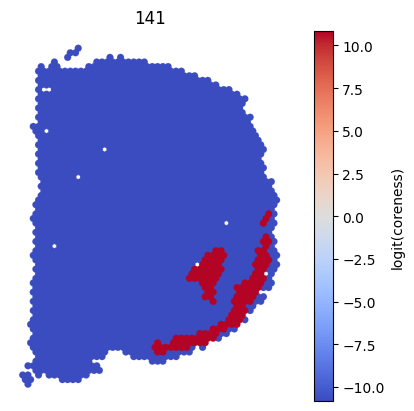

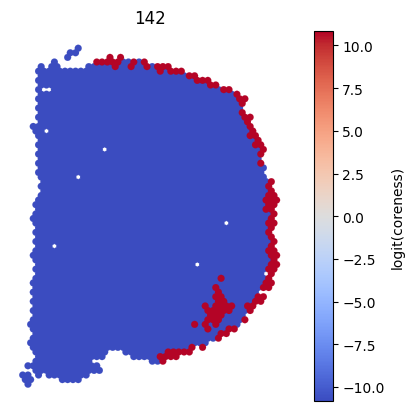

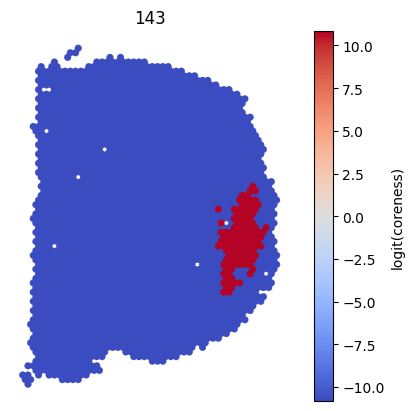

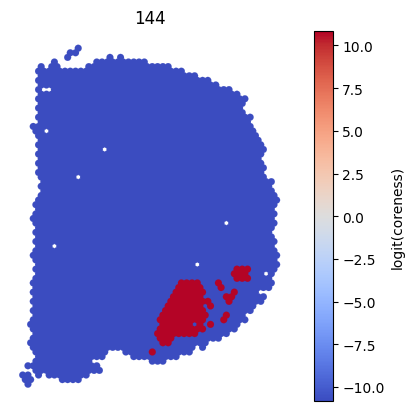

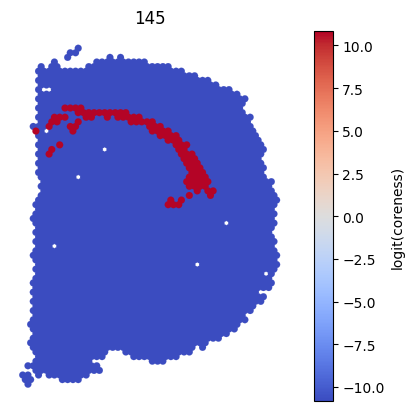

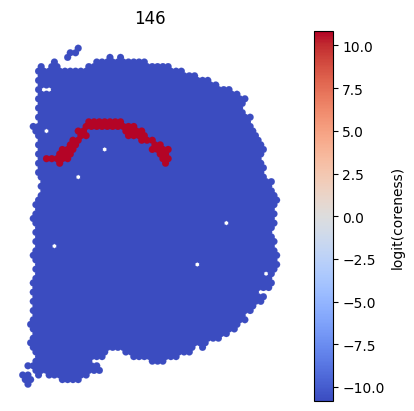

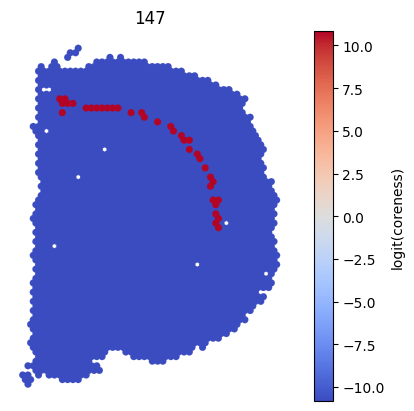

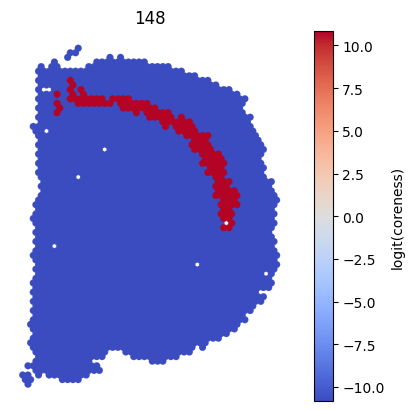

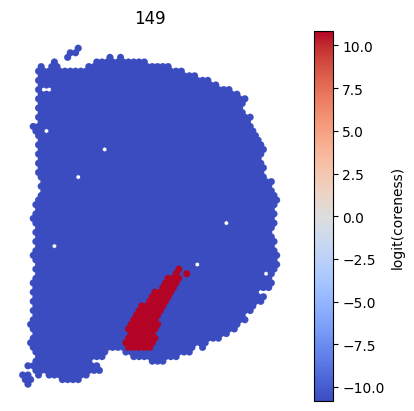

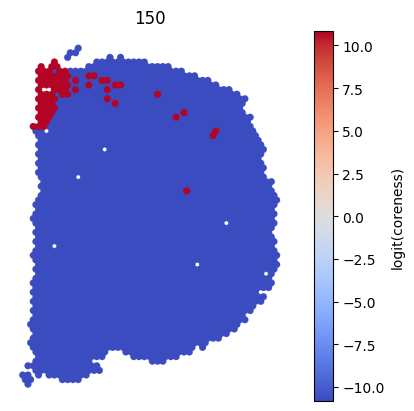

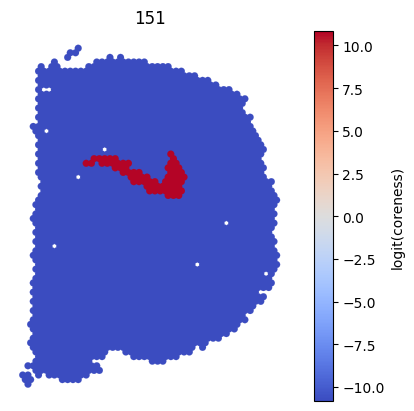

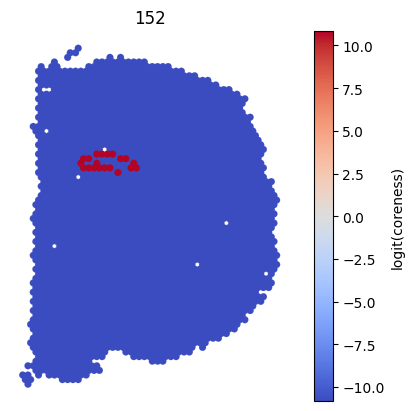

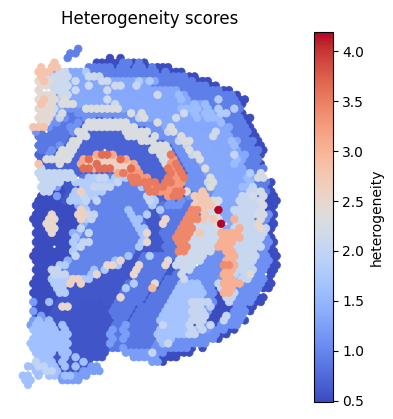

In [ ]:

#Generate multiscale domains
phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=0,filt=0,order='persistence',plots='on');
adata.obsm['multiscale'] = phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=10,filt=0,order='persistence',plots='off')